<a href="https://colab.research.google.com/github/Sparkydev007/COLAB-Notebooks/blob/main/Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
df=pd.read_csv("/content/diabetes.csv")
print(df.head())
print(type(df), df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'> (768, 9)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
x = df.iloc[:, 0:8]
y = df["Outcome"]

# Scaling
scaler = StandardScaler()
x_ = scaler.fit_transform(x)

# Train-test split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    x_, y, test_size=0.1, random_state=42
)

print(Xtrain.shape, Xtest.shape, Ytrain.shape, Ytest.shape)

# Model
model = models.Sequential()

model.add(layers.Dense(100, activation="relu", input_shape=(8,)))
model.add(layers.Dense(75, activation="relu"))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dense(25, activation="relu"))
model.add(layers.Dense(12, activation="relu"))
model.add(layers.Dense(8, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

# Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    Xtrain,
    Ytrain,
    epochs=100,
    validation_data=(Xtest, Ytest)
)

# Evaluate
result = model.evaluate(Xtest, Ytest)
print("Test Loss, Test Accuracy:", result)


(691, 8) (77, 8) (691,) (77,)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.5721 - loss: 0.6852 - val_accuracy: 0.6753 - val_loss: 0.6426
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6981 - loss: 0.5914 - val_accuracy: 0.7013 - val_loss: 0.5485
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7792 - loss: 0.4944 - val_accuracy: 0.7403 - val_loss: 0.5071
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7789 - loss: 0.4605 - val_accuracy: 0.6883 - val_loss: 0.5236
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7808 - loss: 0.4358 - val_accuracy: 0.7273 - val_loss: 0.5181
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7955 - loss: 0.4124 - val_accuracy: 0.7143 - val_loss: 0.5125
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7939 - loss: 0.4147 - val_accuracy: 0.7143 - val_loss: 0.5196
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8077 - loss: 0.3927 - val_accuracy: 0.6753 - val_loss: 0

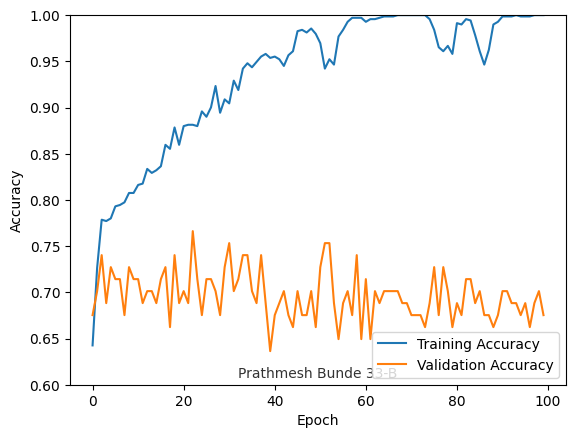

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')

if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.6, 1.0])
plt.legend(loc='lower right')

# Your name on the plot
plt.text(
    0.5, 0.02,
    "Prathmesh Bunde 33-B",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=10,
    alpha=0.8
)

plt.show()
